## **Credit risk modeling with logistic regression**

📖 **Background**

Credit risk modeling is a fundamental component of retail banking and consumer lending. Financial institutions must be able to assess whether a prospective borrower is likely to repay a loan. In this project, a model will be built using logistic regression model to estimate the probability that a personal loan applicant is a bad credit risk. The steps include: explore the data, process the variables, estimate several candidate models, and evaluate out-of-sample performance. Finally, the final model is used to decide whether to extend credit to a new client.

📂 **Data**

The dataset used here — German Credit (OpenML ID 31) — contains 1,000 loan applicants, each labeled as good or bad credit risk. Although the dataset is simplified compared to modern credit bureau data, it contains many typical features seen in consumer lending: repayment history, employment status, financial ratios, personal characteristics, and credit usage.

The dataset contains demographic, financial, and credit-related information for 1,000 loan applicants.
The target variable is class, taking values "good" or "bad".
There are 20 input variables, mostly categorical with several numeric fields.
Source: OpenML.org
Assumptions: Data is stationary and ergodic; you may fit a static model. The data is representative of a single lending market. Ignore regulatory constraints (e.g., fairness, disparate impact) for this exercise.

<h1 style="font-weight: bold; font-size:14px; line-height:1.5em;">🛠 Prepare environment</h1>

In [5]:
from warnings import filterwarnings
filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
colors = sns.color_palette("vlag")

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (OneHotEncoder,PolynomialFeatures,QuantileTransformer, StandardScaler)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel



from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay)

from scipy.special import logit
from IPython.display import display, HTML, Math

SEED = 123
np.random.seed(SEED)

In [6]:
# functions

# display data overview
def data_overview(df: pd.DataFrame) -> pd.DataFrame:
    """
    Provides an overview of columns in a DataFrame.
    Args:df (pd.DataFrame): Input DataFrame.
    Returns:pd.DataFrame: Summary including dtype, missing values, and unique count.
    """
    overview = pd.concat([df.dtypes.rename("Data Type"),
         df.isna().sum().rename("Missingness"),
         df.nunique().rename("# Unique"),],axis=1,)

    return overview

# data prepration: categorical features
class WoEEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.woe_dicts = {}

    def fit(self, X, y):

        X = pd.DataFrame(X).copy()
        y = pd.Series(y)

        eps = 1e-4

        for col in X.columns:

            df = pd.DataFrame({
                'feature': X[col],
                'target': y
            })

            grouped = df.groupby('feature')['target']

            event = grouped.sum()
            non_event = grouped.count() - event

            event_rate = event / event.sum()
            non_event_rate = non_event / non_event.sum()

            woe = np.log((event_rate + eps) /
                         (non_event_rate + eps))

            self.woe_dicts[col] = woe.to_dict()

        return self

    def transform(self, X):

        X = pd.DataFrame(X).copy()

        X_out = pd.DataFrame(index=X.index)

        for col in X.columns:

            mapping = self.woe_dicts[col]

            X_out[col] = X[col].map(
                lambda x: mapping.get(x, 0.0)
            ).astype(float)

        return X_out.astype(float).values

<div style="border-left: 4px solid #DCA8DB; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #f3e0f2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;"> Step One : Data exploration</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Download the credit dataset.
- Summarize each variable using tables and/or visualizations appropriate to the data type.


</p></div></div>

In [7]:
# load credit risk dataset
credit_risk = fetch_openml(data_id=31, as_frame=True, parser="auto").frame
pd.set_option('display.max_columns', None)
credit_risk.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [8]:
df = credit_risk.copy()
display(data_overview(df))

column_types = {"numeric": df.select_dtypes(include=["number"]).columns.tolist(),
    "categorical": df.select_dtypes(include=["object", "category"]).columns.tolist(),
    "datetime": df.select_dtypes(include=["datetime"]).columns.tolist(),
    "boolean": df.select_dtypes(include=["bool"]).columns.tolist(),}


,Data Type,Missingness,# Unique
checking_status,category,0,4
duration,int64,0,33
credit_history,category,0,5
purpose,category,0,10
credit_amount,int64,0,921
savings_status,category,0,5
employment,category,0,5
installment_commitment,int64,0,4
personal_status,category,0,4
other_parties,category,0,3


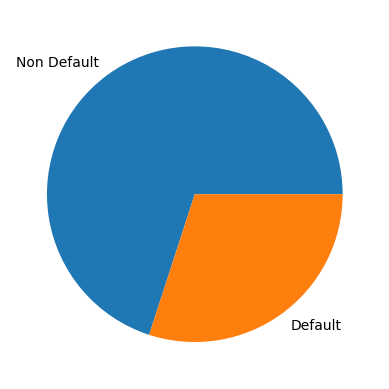

In [9]:
# plot the classes of the target
target  = df["class"].value_counts(normalize = True) * 100
plt.pie(target.values, labels = ['Non Default','Default']);

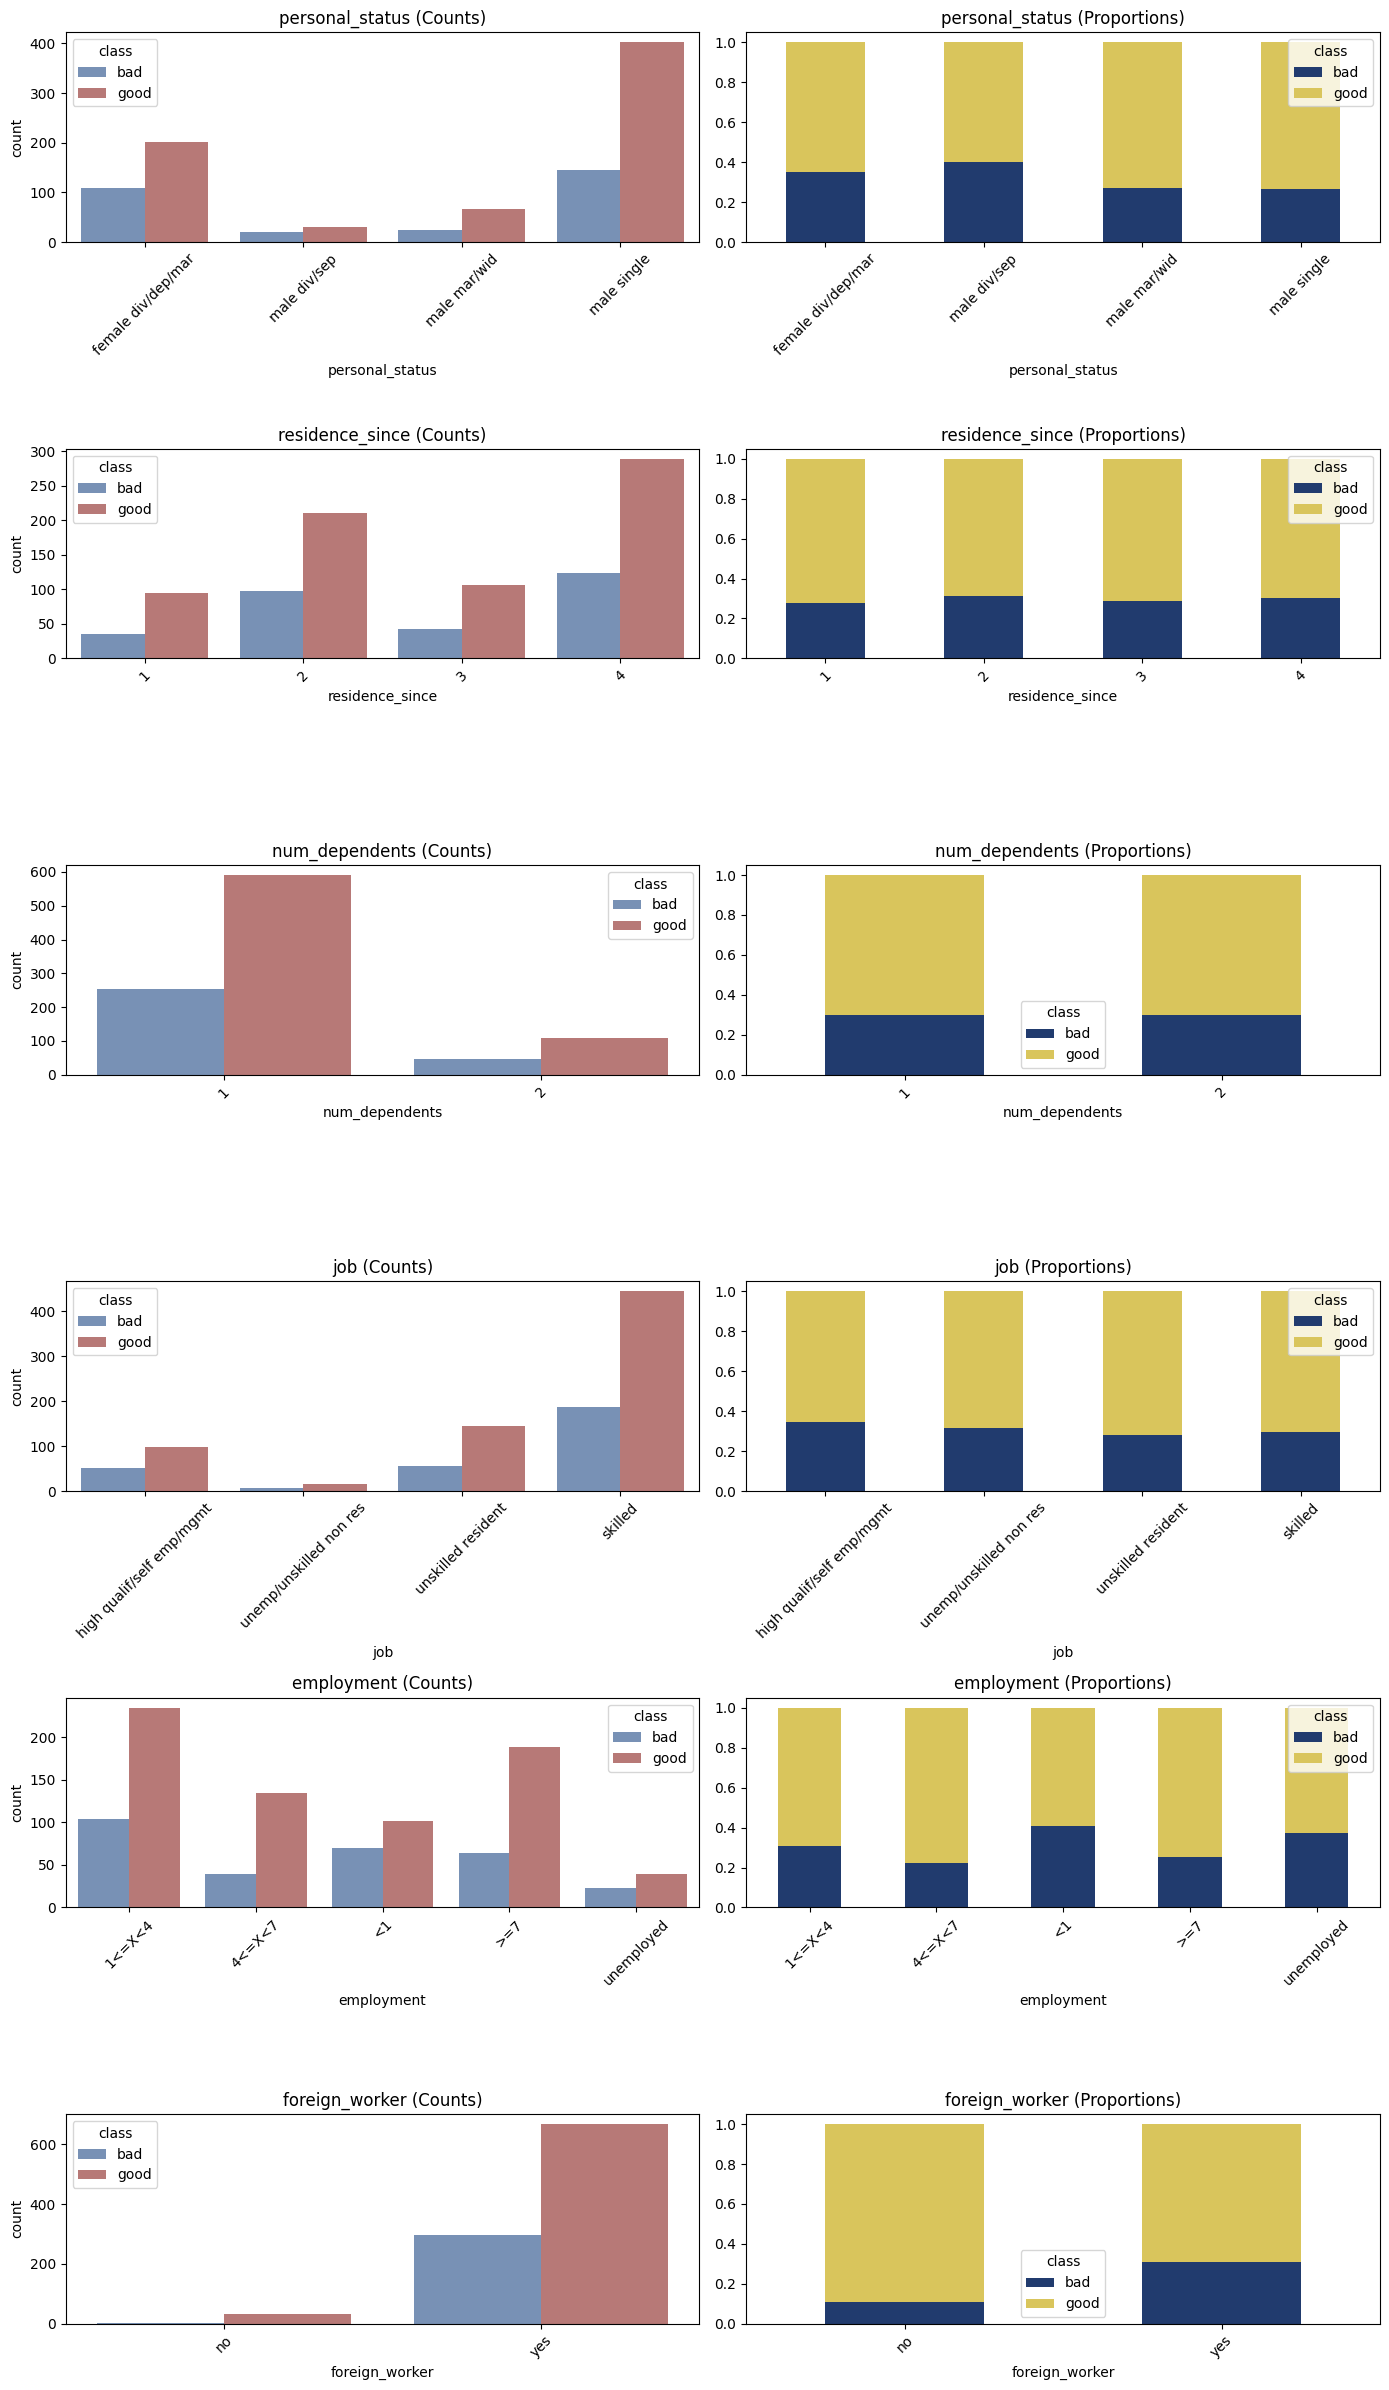

In [10]:
cols = [ "personal_status", "residence_since","num_dependents","job","employment", "foreign_worker"]
colors_2 = sns.color_palette(palette='cividis')

fig, ax = plt.subplots(len(cols), 2, figsize=(14, 4 * len(cols)))
for i, col in enumerate(cols):
    sns.countplot(data=df,x=col,hue="class",palette=[colors[0], colors[5]],ax=ax[i, 0])
    ax[i, 0].set_title(f"{col} (Counts)")
    ax[i, 0].tick_params(axis='x', rotation=45)

    ct = pd.crosstab(df[col], df["class"], normalize="index")
    ct.plot(kind="bar",stacked=True,color=[colors_2[0], colors_2[5]],ax=ax[i, 1])

    ax[i, 1].set_title(f"{col} (Proportions)")
    ax[i, 1].tick_params(axis='x', rotation=45)
    ax[i, 1].legend(title="class")

plt.tight_layout()
plt.show()


The pie chart shows that the dataset is imbalanced, with approximately 70% non-default clients and 30% default clients. This imbalance should be considered during model development and evaluation. To better understand the dataset, the variables were grouped based on their characteristics.
#### 1. Columns Related to Job and Personal Status:
Count plots and stacked cross-tabulations were used to analyze variables related to clients’ personal status, employment, and demographic characteristics.
* Personal Status: More than half of the clients are single males, followed by divorced/dependent/married females, with more than 300 observations. These categories also contain the highest number of default clients. However, when examining the default proportion within each category, approximately 40% of male divorced/separated clients and 38% of divorced/dependent/married female clients are default.
* Residence Since: The residence_since variable represents the number of years the client has lived at their current residence. Clients with 2 and 4 years of residency show higher numbers of defaults. However, the default proportions across all residency categories are relatively similar.
* Number of Dependents:  More than 80% of the clients have only one dependent. The default proportion for both dependent categories is approximately 30%, indicating little difference between the groups.
* Job Category: More than 65% of the clients are skilled workers, while unemployed and unskilled workers represent the smallest group. The default proportion across job categories is relatively similar, with around 35% defaulting in each category.
* Employment Duration: Around 350 clients have between 1 and 4 years of employment experience, followed by clients with more than 7 years of experience. Clients with less than one year of employment experience have the highest default proportion at approximately 40%, followed by unemployed clients at around 39%.
* Foreign Worker Status: Almost 90% of the clients are foreign workers, and approximately 35% of them defaulted. In comparison, only about 10% of non-foreign workers defaulted.

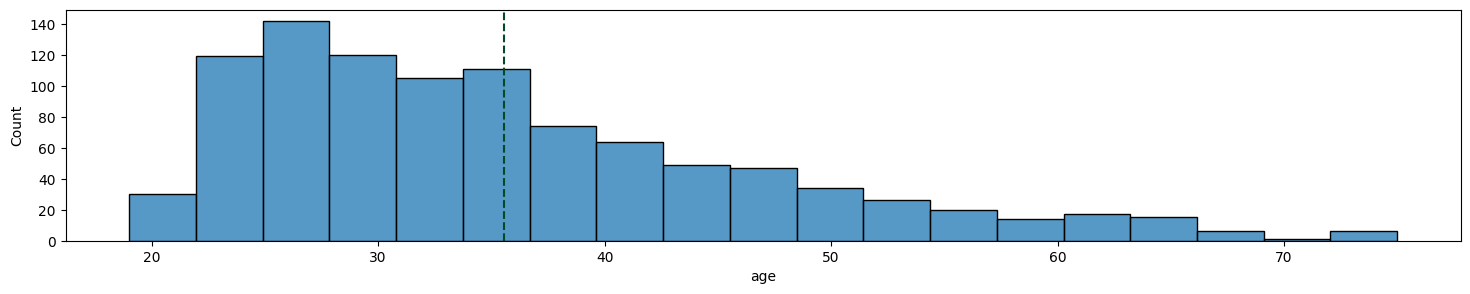

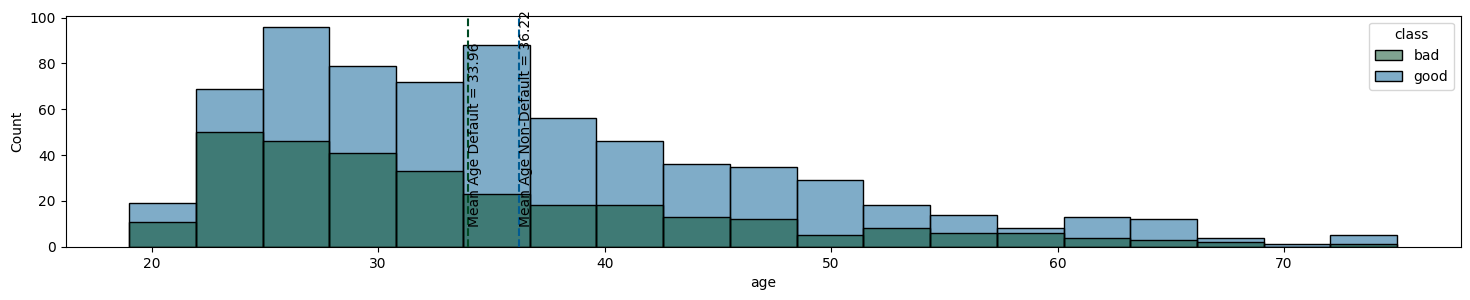

In [11]:
colors = sns.color_palette(palette='ocean')
age_df = df.groupby("class")["age"].mean()

fig = plt.figure(figsize=(18,3))
sns.histplot(data=df, x="age")
plt.axvline(df['age'].mean(), linestyle='--', label='Mean Age Default', color = colors[0])
plt.show()

fig = plt.figure(figsize=(18,3))
sns.histplot(data=df, x="age", hue="class", palette= [colors[0],colors[3]])
plt.axvline(age_df['bad'], linestyle='--', label='Mean Age Default', color = colors[0])
plt.axvline(age_df['good'], linestyle='--', label='Mean Age Non-Default', color = colors[3])
mean_d = age_df['bad']
mean_nond = age_df['good']
plt.text(age_df['bad'], 10, f'Mean Age Default = {mean_d:.2f}', rotation=90)
plt.text(age_df['good'], 10, f'Mean Age Non-Default = {mean_nond:.2f}', rotation=90)
plt.show()

The first histogram shows the distribution of clients’ ages. The distribution is right-skewed, with a mode around 25 years and a mean of approximately 35 years, indicating a concentration of younger clients with a tail extending toward older ages.
The second histogram, which is stratified by class (default vs non-default), reveals a difference in age distributions between the two groups. The mean age of defaulted clients is approximately 34 years, which is slightly lower than the mean age of non-defaulted clients (about 36.22 years). This suggests that younger clients tend to have a higher likelihood of default, although the separation is not very strong and there is still substantial overlap between the two distributions.

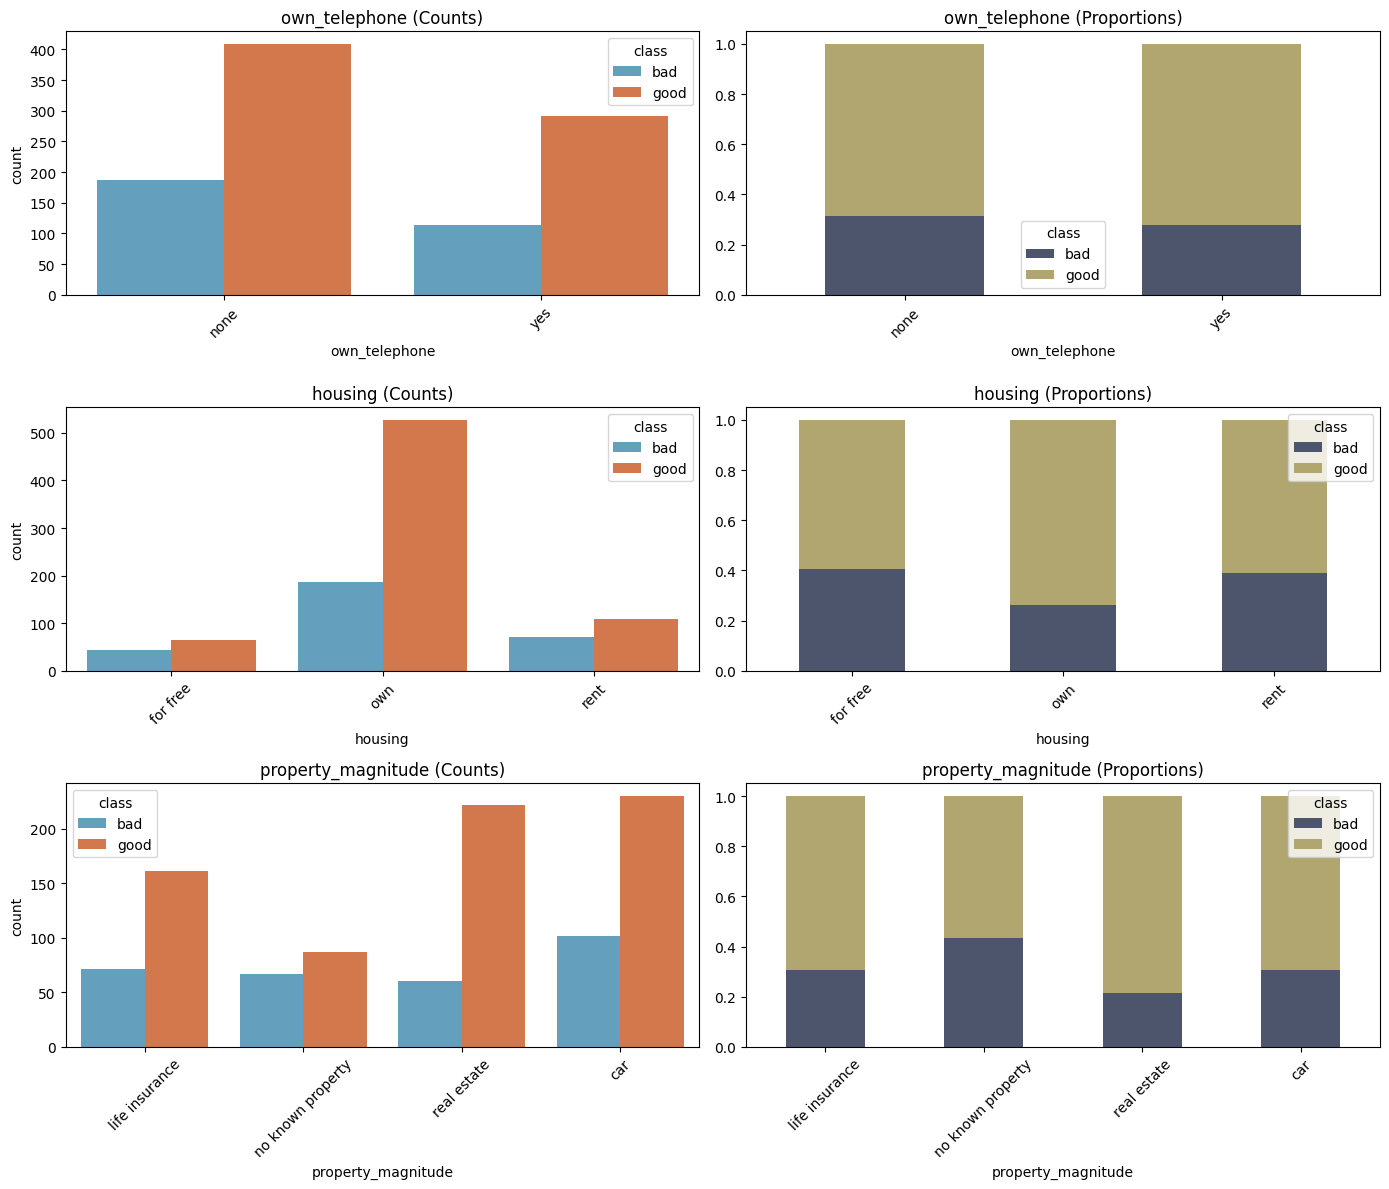

In [12]:
# propety columns
colors = sns.color_palette(palette='icefire')

cat = ["own_telephone", "housing", "property_magnitude"]
fig, ax = plt.subplots(len(cat), 2, figsize=(14, 4 * len(cat)))
for i, col in enumerate(cat):
    sns.countplot(data=df,x=col,hue="class",palette=[colors[0], colors[5]],ax=ax[i, 0])
    ax[i, 0].set_title(f"{col} (Counts)")
    ax[i, 0].tick_params(axis='x', rotation=45)

    ct = pd.crosstab(df[col], df["class"], normalize="index")
    ct.plot(kind="bar",stacked=True,color=[colors_2[1], colors_2[4]],ax=ax[i, 1])

    ax[i, 1].set_title(f"{col} (Proportions)")
    ax[i, 1].tick_params(axis='x', rotation=45)
    ax[i, 1].legend(title="class")

plt.tight_layout()
plt.show()

#### 2-Features related to housing and property
These features indicate that most clients own a house, and among property types, cars are the most common form of property, followed by real estate. Approximately 40% of clients who either rent their residence or live for free fall into the default category. The same proportion of default is seen for clients who have no clearly defined property ownership. This suggests that weaker housing stability or lack of formal property ownership is associated with higher default risk. In contrast, clients with owned housing or tangible assets such as real estate or vehicles tend to exhibit lower default proportions, indicating that property ownership may serve as a proxy for financial stability and creditworthiness.

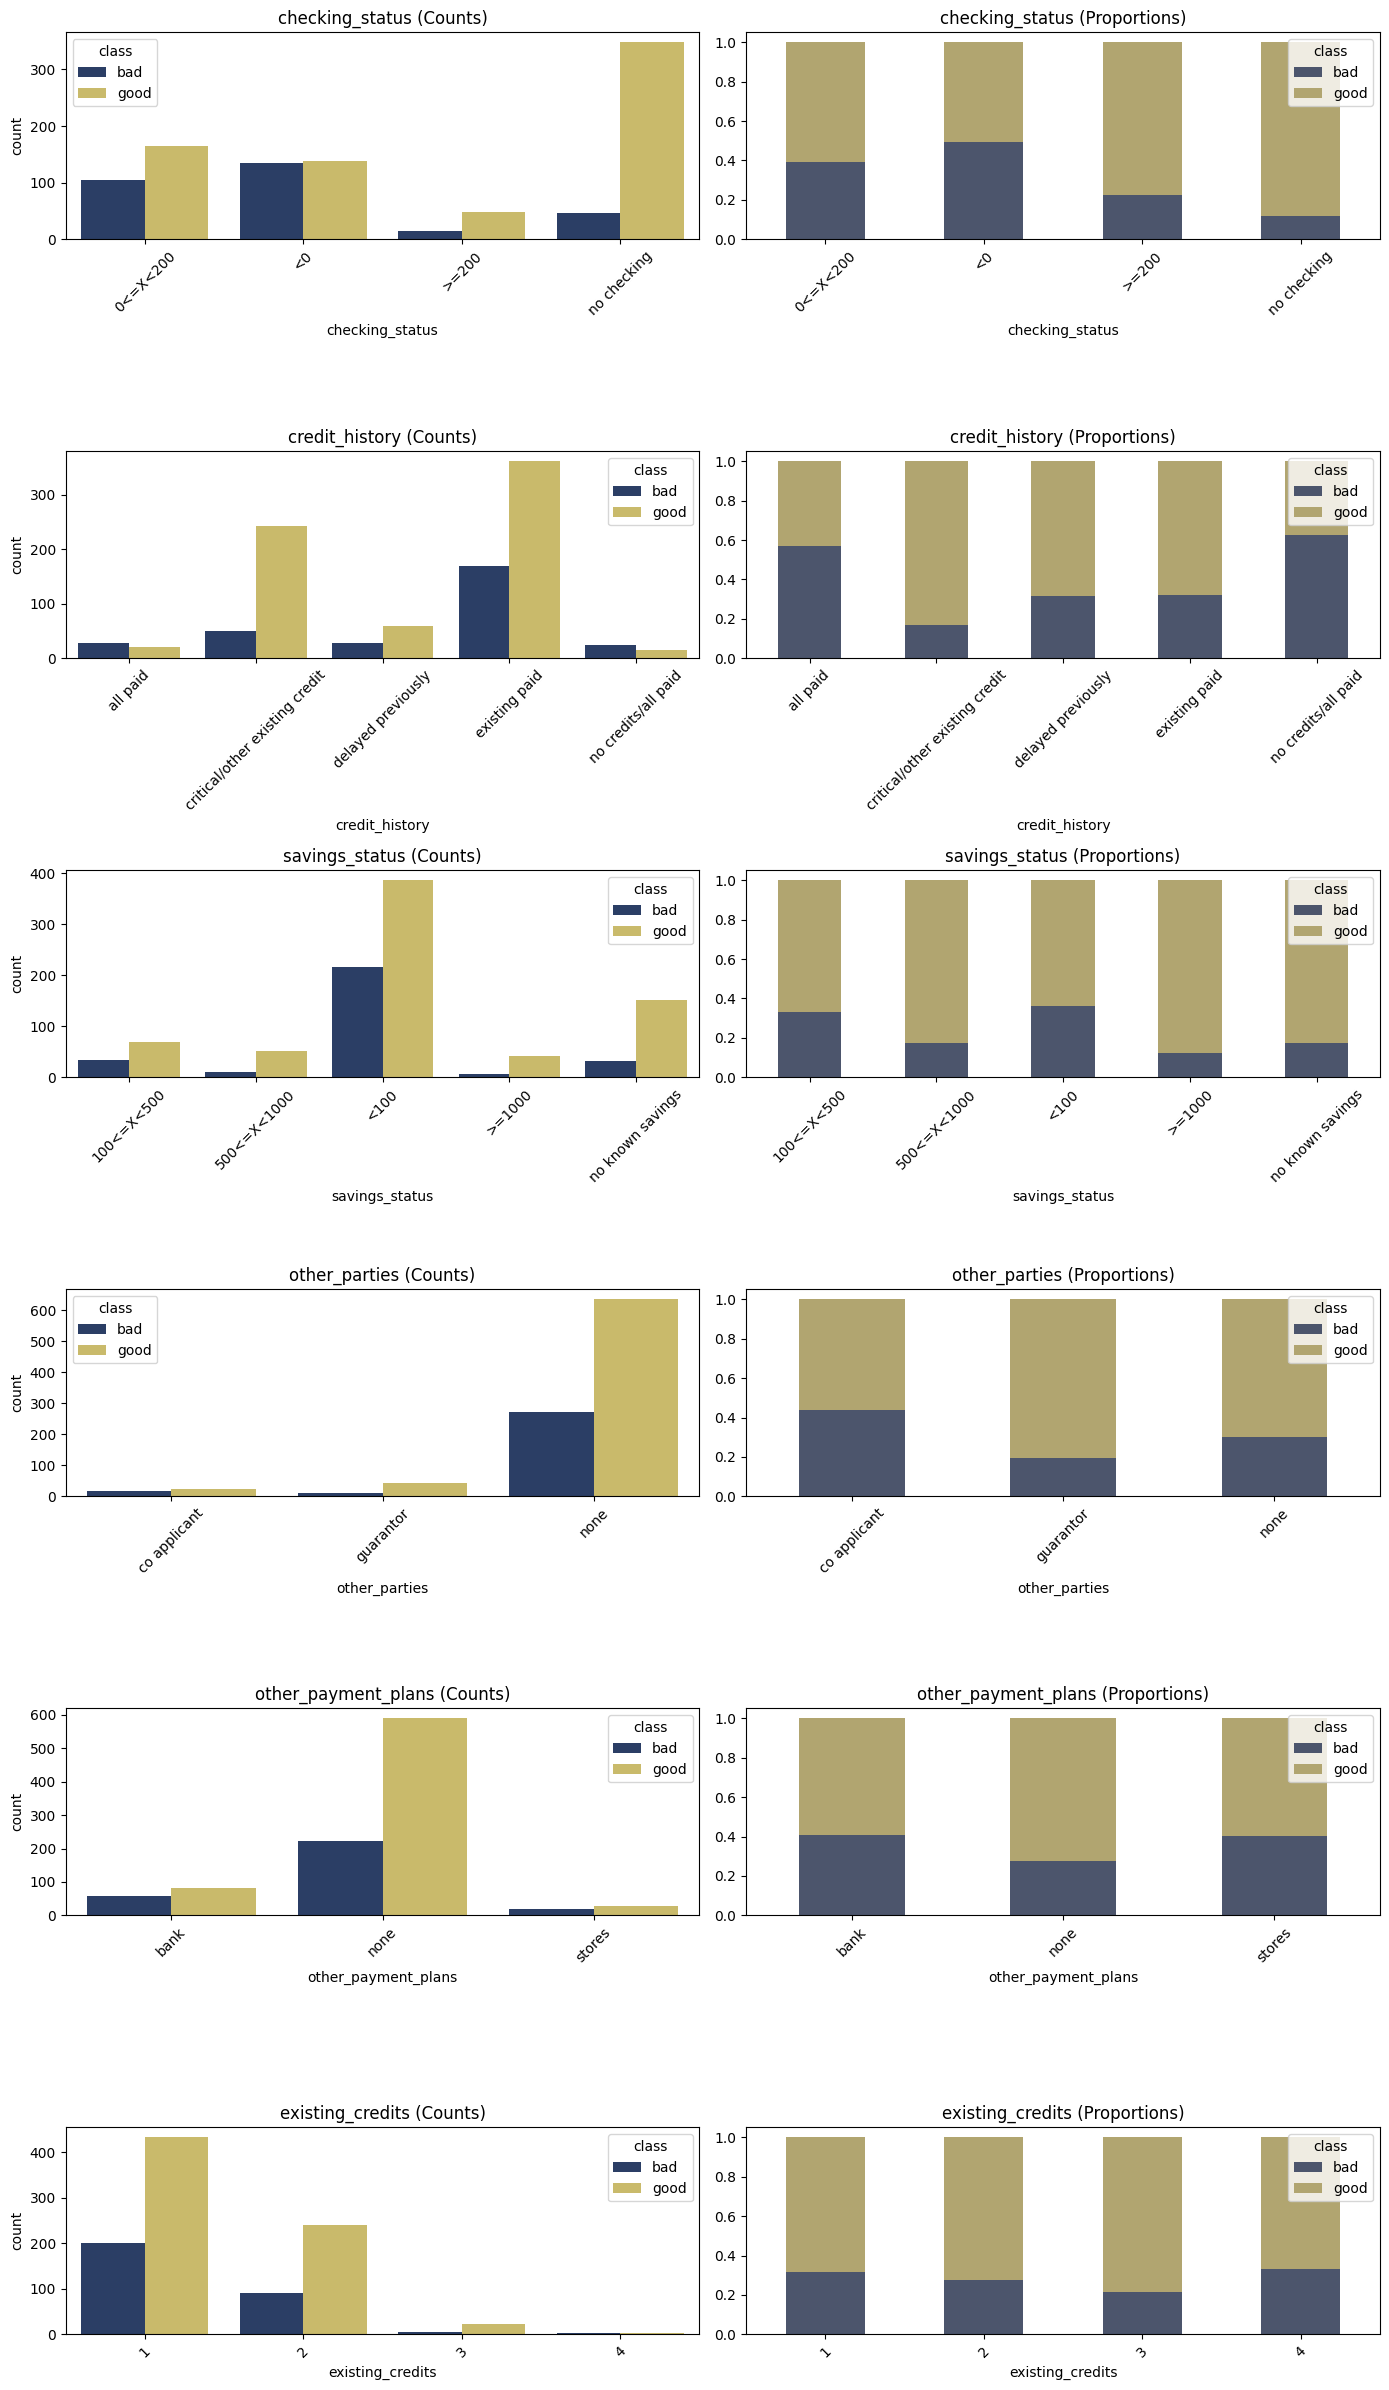

In [13]:
# account and loan related columns: checking_status,
colors = sns.color_palette(palette='cividis')
cat_3 = ['checking_status','credit_history','savings_status','other_parties','other_payment_plans', 'existing_credits']
fig, ax = plt.subplots(len(cat_3), 2, figsize=(14, 4 * len(cat_3)))
for i, col in enumerate(cat_3):
    sns.countplot(data=df,x=col,hue="class",palette=[colors[0], colors[5]],ax=ax[i, 0])
    ax[i, 0].set_title(f"{col} (Counts)")
    ax[i, 0].tick_params(axis='x', rotation=45)

    ct = pd.crosstab(df[col], df["class"], normalize="index")
    ct.plot(kind="bar",stacked=True,color=[colors[1], colors[4]],ax=ax[i, 1])

    ax[i, 1].set_title(f"{col} (Proportions)")
    ax[i, 1].tick_params(axis='x', rotation=45)
    ax[i, 1].legend(title="class")

plt.tight_layout()
plt.show()

#### 3- Features related to clients' accounts
Regarding the account-related features, the most notable variable is credit_history. The cross-tabulation indicates that nearly 60% of clients who have either paid all previous credits or have no prior credit history belong to the default class. A similarly high default proportion is also observed among clients whose previous credits were fully paid. This may suggest that the absence of an established and active credit record does not necessarily indicate a higher risk.
Additionally, the other_parties feature, which indicates the presence of other debtors or guarantors, shows that approximately 40% of clients with a co-applicant are in the default category. This could indicate that applicants requiring financial support or shared liability may exhibit relatively higher credit risk compared to clients applying independently.

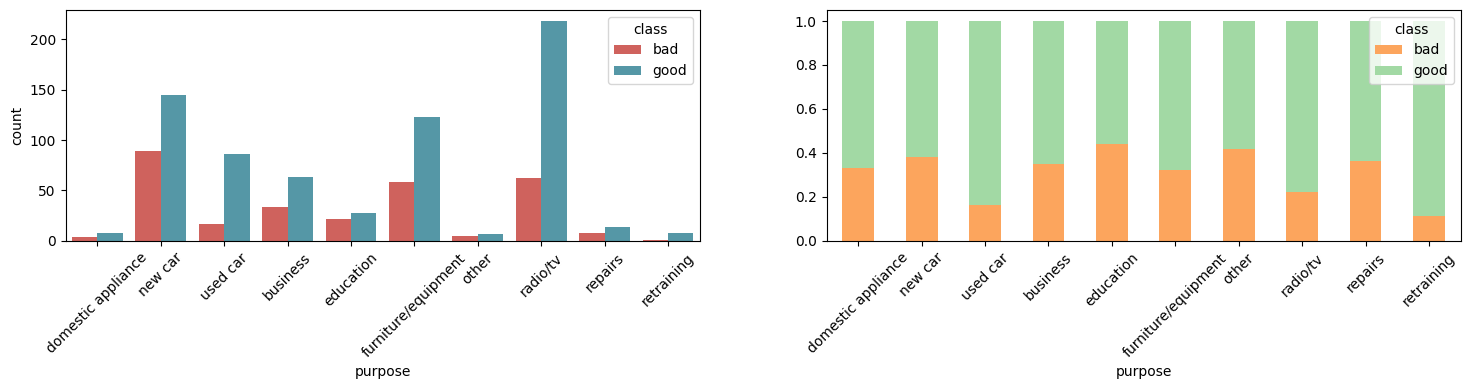

In [14]:
colors = sns.color_palette(palette='Spectral')
fig,axes = plt.subplots(1,2,figsize=(18,3))
sns.countplot(df, x = "purpose",  hue ="class",palette= [colors[0],colors[5]], ax = axes[0])
axes[0].tick_params(axis='x', rotation=45)

ct = pd.crosstab(df['purpose'], df["class"], normalize="index")
ct.plot(kind="bar",stacked=True,color=[colors[1], colors[4]],ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)

plt.show()

Regarding the purpose feature, more than a quarter of the clients (approximately 280) applied for credit to purchase a radio or television, followed by about 234 clients seeking financing for a new car.
However, the proportion analysis provides more meaningful insight into risk behavior. Approximately 40% of clients applying for loans related to a new car, education, furniture/equipment, or repairs belong to the default class.

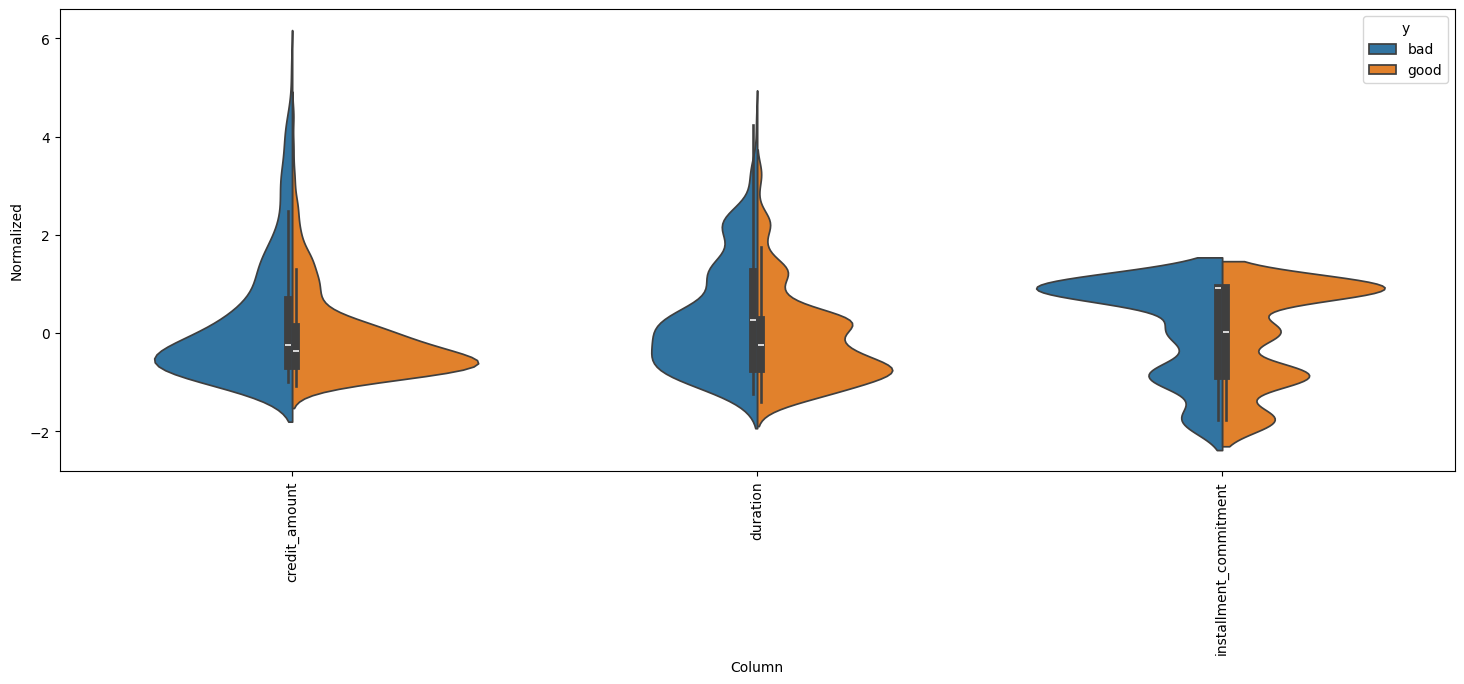

In [15]:
dist_x = df[['credit_amount', 'duration', 'installment_commitment']]
target = df['class']

X_mean = dist_x.mean()
X_std = dist_x.std()
X_std = (dist_x - X_mean) / X_std
X_std["y"] = target
X_std = X_std.melt(id_vars=["y"], var_name="Column", value_name="Normalized")
plt.figure(figsize=(18, 6))
ax = sns.violinplot(data=X_std, x="Column", y="Normalized", hue="y", split=True)
_ = ax.set_xticklabels(dist_x.keys(), rotation=90)

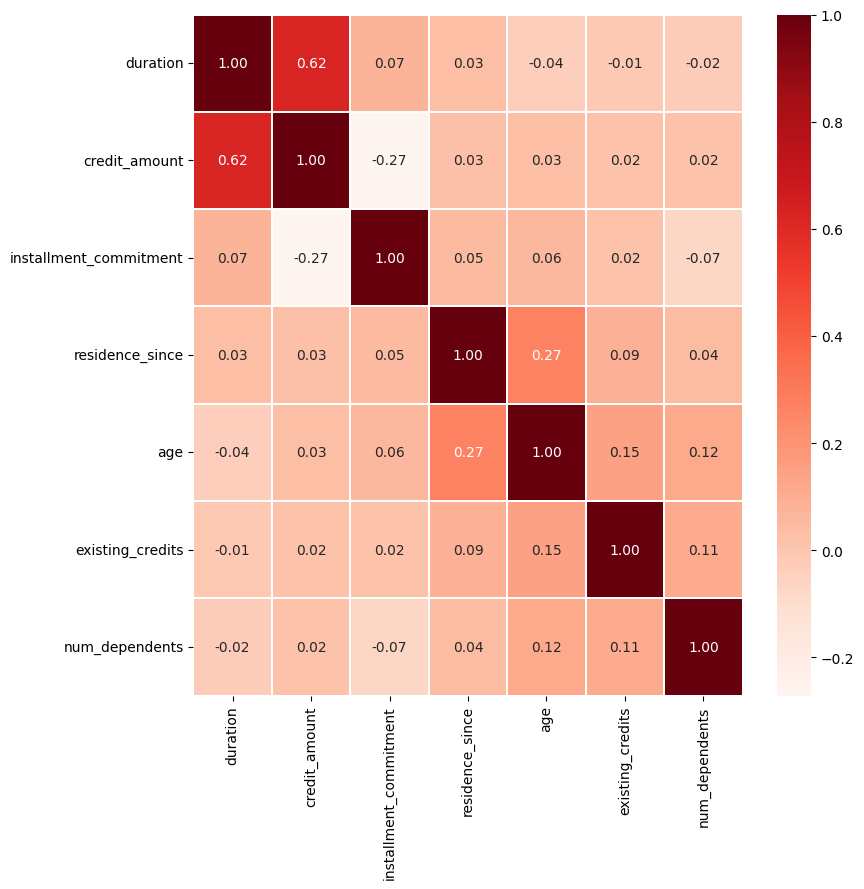

In [16]:
num_c = column_types['numeric']
correlation_matrix = df[num_c].corr()
fig = plt.figure(figsize=(9, 9))
sns.heatmap(correlation_matrix, annot = True, cmap='Reds', fmt=".2f", linewidths=.1)
plt.tight_layout()
plt.show()

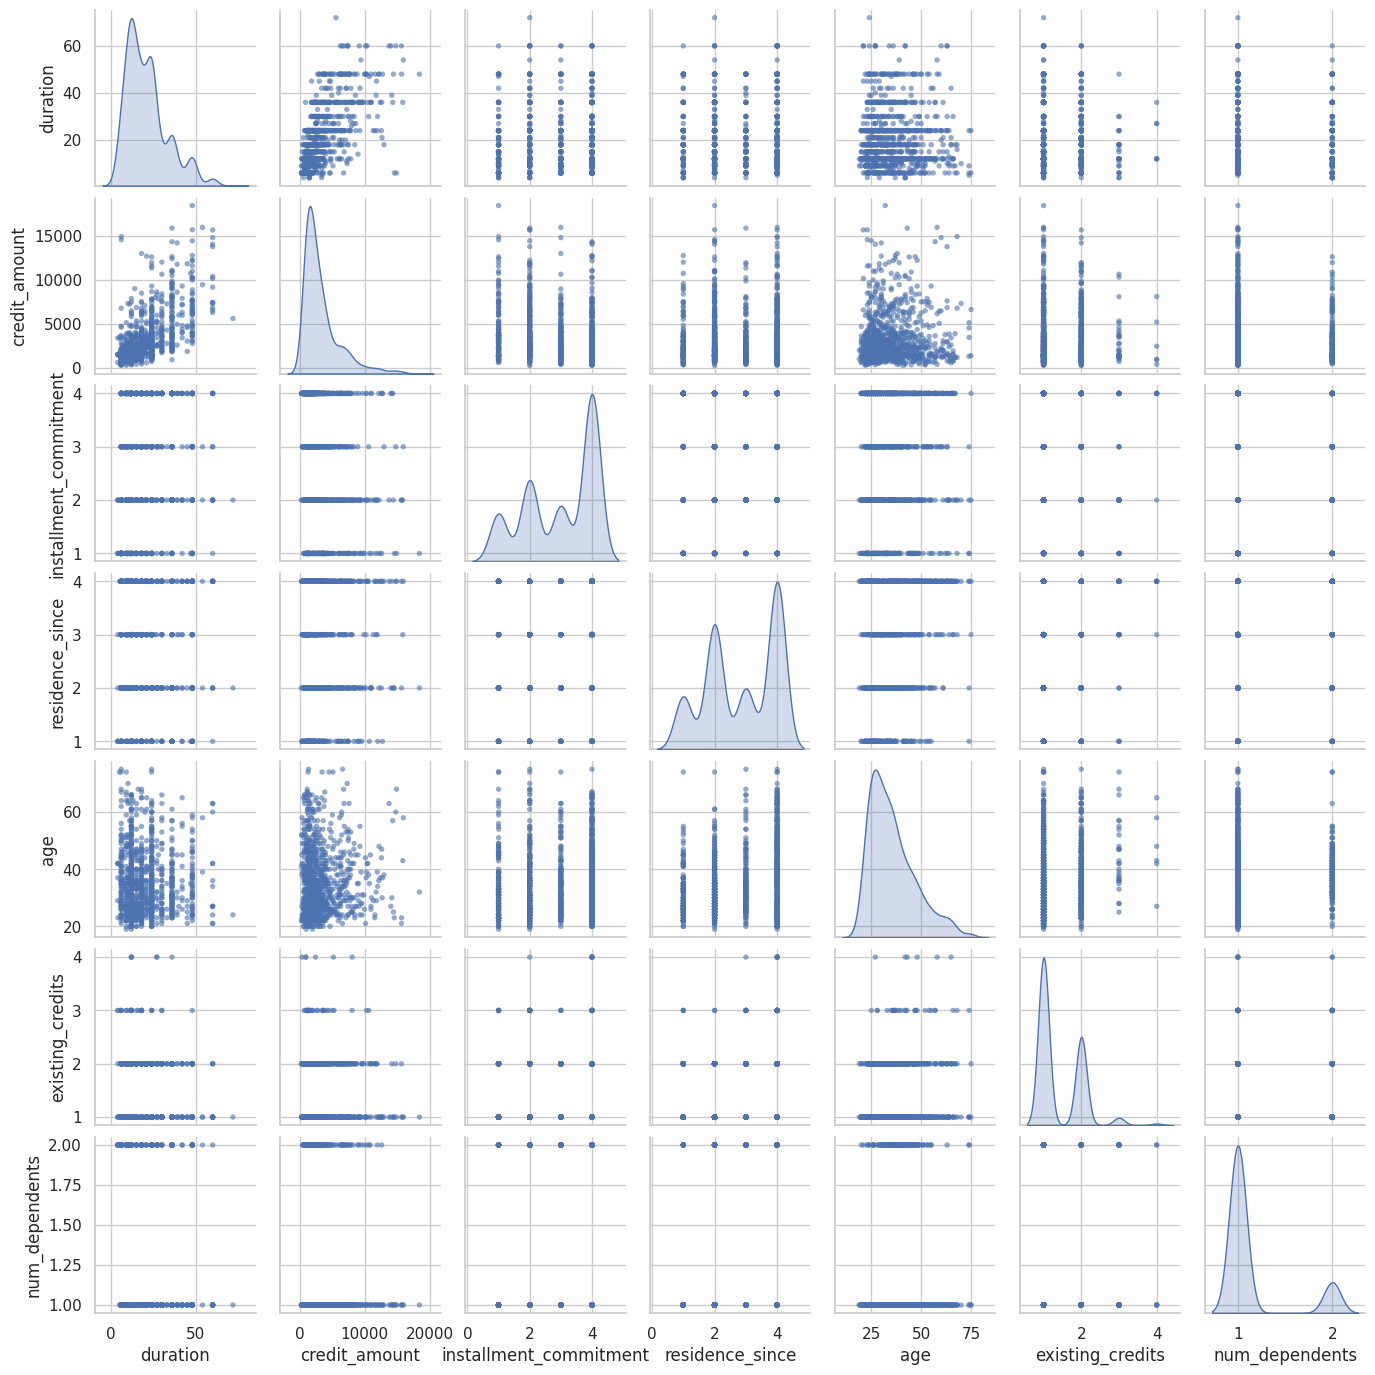

In [17]:
sns.set(style="whitegrid")

sns.pairplot(df[num_c],diag_kind="kde",plot_kws={"alpha": 0.6, "s": 15, "edgecolor": "none"},diag_kws={"fill": True},height=2)

Regarding the numerical variables, duration, credit amount, and age exhibit right-skewed distributions, indicating that most applicants have relatively low values, with a small number of observations taking substantially larger values.
A moderate positive correlation (approximately 0.62) is observed between credit amount and duration, suggesting that larger loans tend to be associated with longer repayment periods. The scatter plot also indicates an approximately linear relationship between these two variables.

<div style="border-left: 4px solid #DCA8DB; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #f3e0f2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">Step Two: Data preparation</h1>
  </div>
  <div style="padding: 1em;">
  <p>


</p></div></div>

In [18]:
# transfor binary variables:class,foreign_worker  to integres
df['class'] = df['class'].replace(['good','bad'], [0,1]).astype(int)
df['foreign_worker'] = df['foreign_worker'].replace(['yes','no'], [1,0]).astype(int)
df['own_telephone'] = df['own_telephone'].replace(['none','yes'], [0,1]).astype(int)
# change categories of purpose variable to prevent multicollinearity
mapping = {"radio/tv": "furniture/equipment/appliance","furniture/equipment": "furniture/equipment/appliance","domestic appliance": "furniture/equipment/appliance",
            "new car": "vehicle", "used car": "vehicle",
            "business": "income_investment","education": "income_investment","retraining": "income_investment",
            "repairs": "repairs/other","other": "repairs/other"}

df["purpose"] = df["purpose"].map(mapping)


In [19]:
# split data
X = df.drop(columns = ['class'], axis = 1)
y = df['class']

x_train, X_test, y_trai, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify = y)
X_train, x_val, y_train, y_val = train_test_split(x_train, y_trai, test_size=0.15, random_state=42, stratify = y_trai)

column_types_X_train = {"numeric": X_train.select_dtypes(include=["number",'int64','float']).columns.tolist(),
    "categorical": X_train.select_dtypes(include=["object", "category"]).columns.tolist(),
    "datetime": X_train.select_dtypes(include=["datetime"]).columns.tolist(),
    "boolean": X_train.select_dtypes(include=["bool"]).columns.tolist(),}

<div style="border-left: 4px solid #DCA8DB; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #f3e0f2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">Step Three: Model estimation</h1>  
  </div>
  <div style="padding: 1em;">
  <p>

- Build a logistic regression model on the training data, applying appropriate feature engineering techniques and regularization.
- Display the ROC curve and AUC for the chosen model. Note these should be computed using the training data at this stage.
- Create a probabilistic predictor from the chosen model.


</p></div></div>

In [20]:
def model_estimation(x_train, y_train, x_val, y_val, model):
    model_fit = model.fit(x_train, y_train)  # fit model
    prob = model_fit.predict_proba(x_val)[:, 1]  # predict probs
    confusion = confusion_matrix(y_val, model_fit.predict(x_val))  # confusion matrix

    error = -sum(np.log(prob[prob>0]))/len(prob[prob>0])  # log error

    fp_rate, tp_rate, _ = roc_curve(y_val, prob)
    auc_test = auc(fp_rate, tp_rate)  # auc on test set

    # conditional scores
    s_0 = logit(model_fit.predict_proba(x_val)[np.where(y_val == 0)[0], 1]) #log odds for all actual negatives
    s_1 = logit(model_fit.predict_proba(x_val)[np.where(y_val == 1)[0], 1]) #log odds for all actual positive
    return fp_rate, tp_rate,s_0, s_1, confusion, error, auc_test


def result_plot(fpr, tpr, s_0, s_1, confusion, error, auc_score, y_val):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ROC curve
    axes[0].plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
    axes[0].plot([0, 1], [0, 1], linestyle='--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    axes[0].grid(True)

    # Score distributions
    sns.histplot(x=s_0, stat='density', label='S|0', ax=axes[1], kde=True)
    sns.histplot(x=s_1, stat='density', label='S|1', ax=axes[1], kde=True)
    axes[1].set_title('Score Distribution')
    axes[1].legend()
    axes[1].set_ylabel('Density')

    # Error rates
    fpr_rate = confusion[0, 1] / sum(y_val == 0)
    fnr_rate = confusion[1, 0] / sum(y_val == 1)

    sns.barplot(
        x=['FPR', 'FNR'],
        y=[fpr_rate, fnr_rate],
        ax=axes[2]
    )
    axes[2].set_title('Classification Errors')
    axes[2].set_ylabel('Rate')

    plt.tight_layout()
    plt.show()

Feature Engineering methods on numerical variables:
| Feature | Description | Feature Engineering Method |
|----------|----------|----------|
| duration | Numerical, Right-Skewed | Quantile Transformer |
| credit_amount | Numerical, Right-Skewed | Quantile Transformer |
| installment_commitment | Numerical, Ordinal | Standard Scaler |
| residence_since | Numerical, Ordinal | Standard Scaler |
| age | Numerical, Right-Skewed | Quantile Transformer |
| existing_credits | Numerical, Ordinal | Standard Scaler |
| num_dependents | Binomial | None |

##### Model Development
Three logistic regression models were developed using different feature engineering techniques to determine the most effective approach for predicting credit default.
Model 1: Numerical Features Only: The first model uses only numerical variables. To address skewness and improve the suitability of the data for logistic regression:
- A Quantile Transformer with a normal output distribution was applied to skewed numerical variables.
- A StandardScaler was applied to the remaining numerical and ordinal variables.
These transformations help standardize feature distributions and reduce the influence of outliers. After preprocessing, a logistic regression classifier was fitted to the transformed numerical features.
Model 2: Numerical and Categorical Features with One-Hot Encoding: The second model incorporates both numerical and categorical variables.
Feature engineering consisted of:
- Applying a QuantileTransformer to skewed numerical variables.
- Applying a StandardScaler to the remaining numerical and ordinal variables.
- Applying One-Hot Encoding to categorical variables to convert them into binary indicator variables.
The transformed features were then used to train a logistic regression model.
Model 3: Numerical and Categorical Features with Weight of Evidence Encoding: The third model also uses all available features but employs Weight of Evidence (WoE) encoding for categorical variables. Feature engineering consisted of:
- Applying a Quantile Transformer to skewed numerical variables.
- Applying a StandardScaler to the remaining numerical and ordinal variables.
- Applying Weight of Evidence (WoE) encoding to categorical variables.
WoE encoding is widely used in credit risk modelling because it captures the relationship between predictor categories and the target variable while preserving a monotonic relationship with the log-odds of default. The transformed features were then used to train a logistic regression model.
##### Model Evaluation
The models were evaluated using the **Area Under the Receiver Operating Characteristic Curve (AUC-ROC). The ROC curve evaluates a classifier across all possible classification thresholds based on its predicted probabilities. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) for different threshold values.
The True Positive Rate is defined as:
$$
TPR = \frac{TP}{TP + FN}
$$
where:
- TP = True Positives
- FN = False Negatives
The False Positive Rate is defined as:
$$
FPR = \frac{FP}{FP + TN}
$$
where:
- FP = False Positives
- TN = True Negatives
The AUC summarizes the ROC curve into a single value ranging from 0 to 1. A higher AUC indicates better discrimination between default and non-default customers. Since AUC is threshold-independent, it is particularly suitable for comparing credit risk models and evaluating performance on imbalanced datasets.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

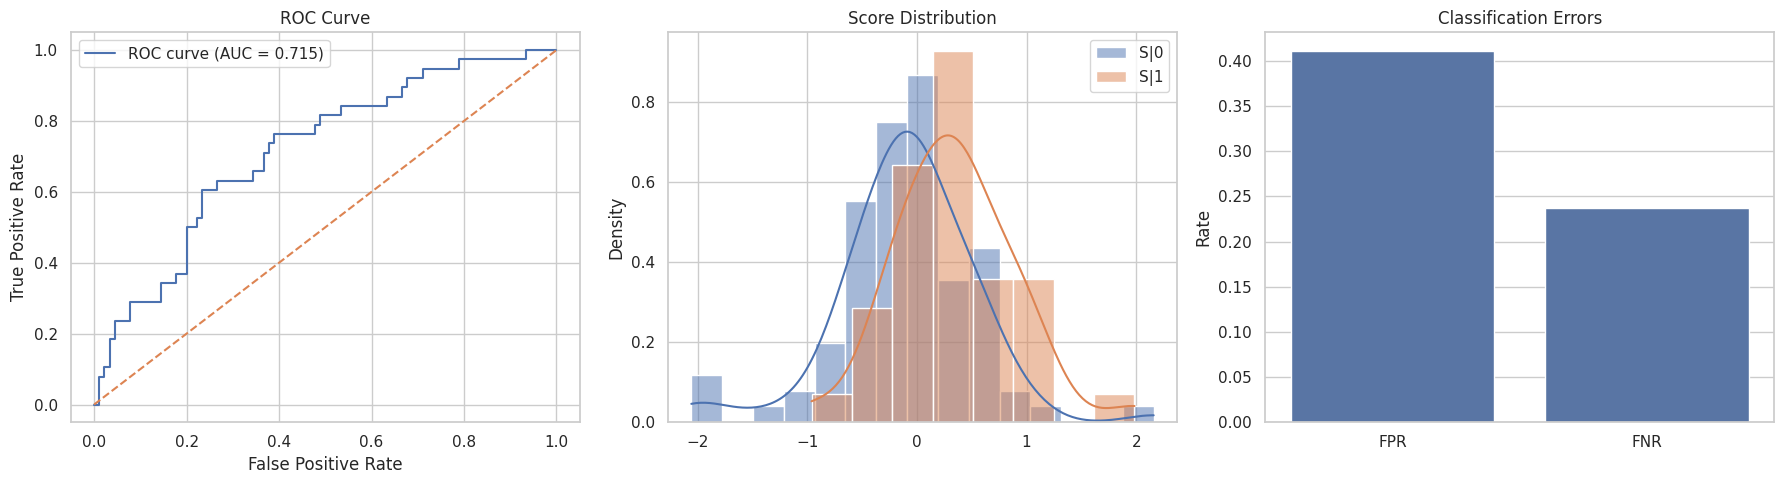

<IPython.core.display.Math object>

<IPython.core.display.Math object>

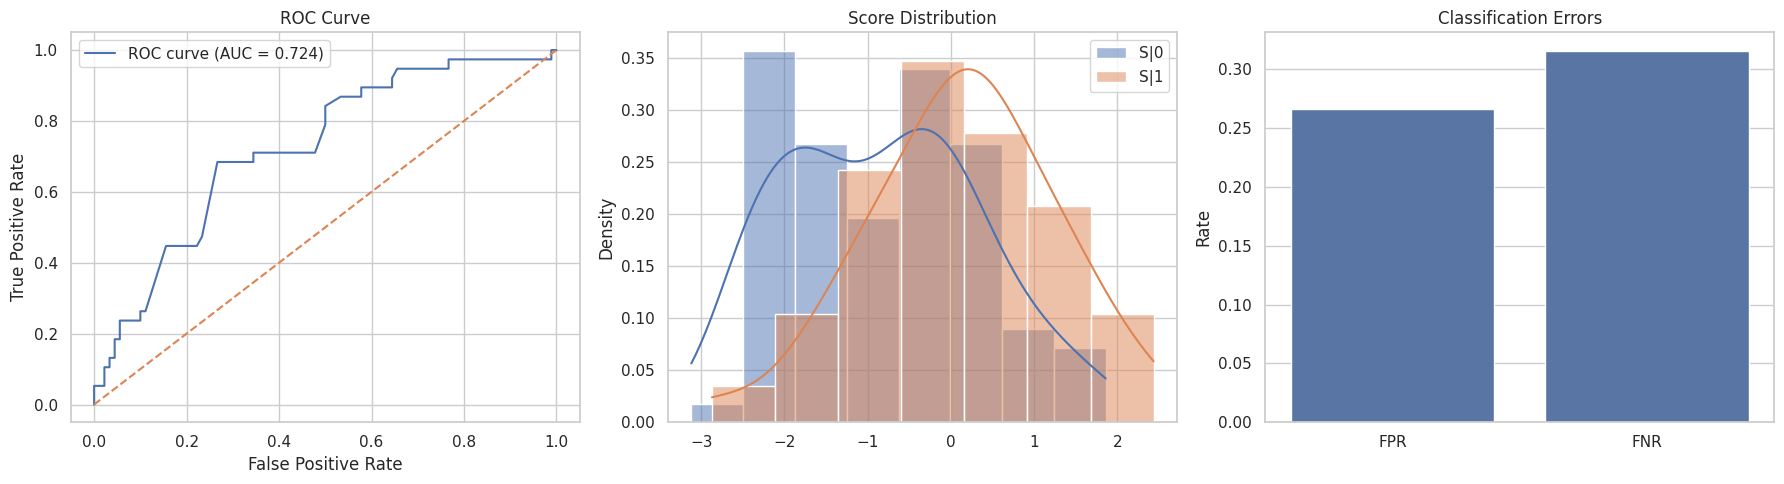

<IPython.core.display.Math object>

<IPython.core.display.Math object>

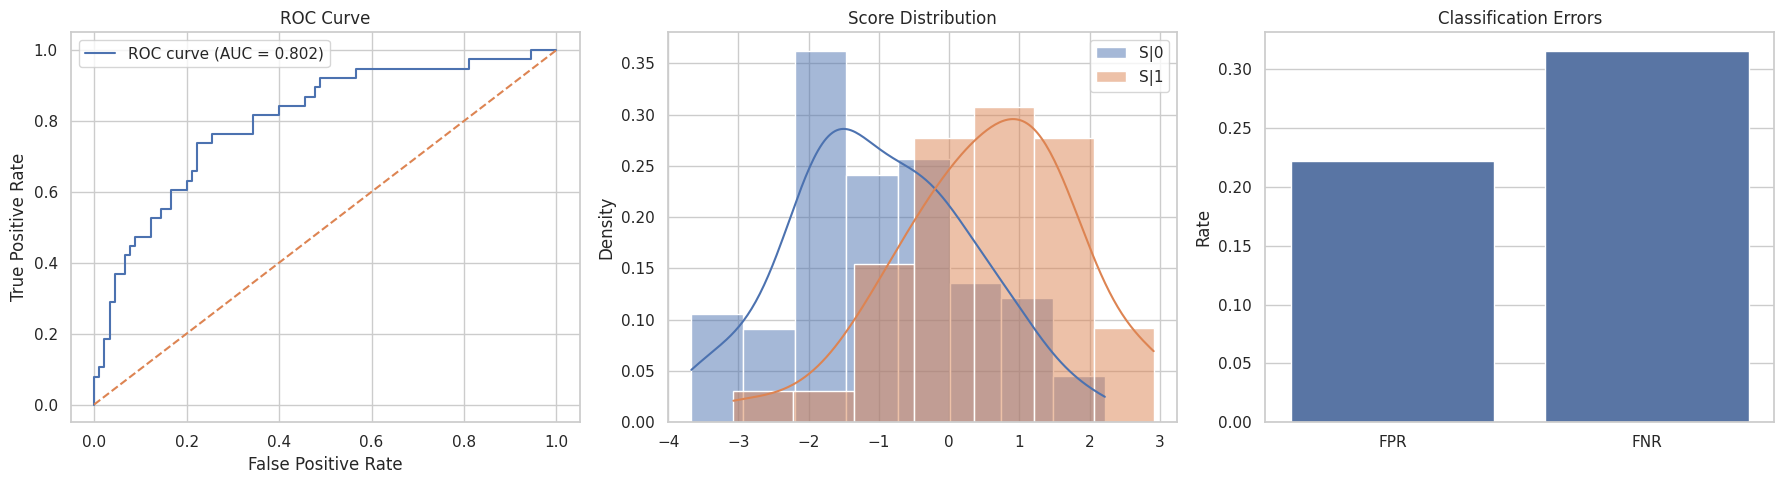

In [21]:
# model1
# continuous data + logestic regression
X_train_num = X_train[column_types_X_train['numeric']]
x_val_num = x_val[column_types_X_train['numeric']]

normal_feat = ['duration', 'credit_amount', 'age']
scaler_feat = ['installment_commitment','residence_since','existing_credits','num_dependents','own_telephone','foreign_worker']

ct_1 = ColumnTransformer([('normaltransfer', QuantileTransformer(output_distribution='normal'),normal_feat,),
                        ('scaler',StandardScaler() , scaler_feat)] )

lg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=20000,class_weight='balanced')

pipe_lg_con = make_pipeline(ct_1, lg)

fpr_1, tpr_1,s_0_1, s_1_1, confusion_1, error_1, auc_c1 = model_estimation(X_train_num, y_train, x_val_num, y_val, pipe_lg_con)

display(Math(r"error = " + str(error_1.round(2))))
display(Math(r"auc = " + str(auc_c1.round(3))))
result_plot(fpr_1, tpr_1,s_0_1, s_1_1, confusion_1, error_1, auc_c1, y_val)

#********************************************************************************************************************************************************************************************
# model 2
# continious data + onehot encoding + logestic regression
ct_2 = ColumnTransformer([('normaltransfer', QuantileTransformer(output_distribution='normal'),normal_feat,),
                        ('scaler',StandardScaler() , scaler_feat),
                        ('onehot', OneHotEncoder(drop="first", dtype=int, sparse_output=False), column_types_X_train['categorical'])] )
select_lr = SelectFromModel(Ridge(), threshold="mean")
pipe_lg_con_cat = make_pipeline(ct_2,select_lr, lg)

fpr_2, tpr_2,s_0_2, s_1_2, confusion_2, error_2, auc_c2 = model_estimation(X_train, y_train, x_val, y_val, pipe_lg_con_cat)

display(Math(r"error = " + str(error_2.round(2))))
display(Math(r"auc = " + str(auc_c2.round(3))))

result_plot(fpr_2, tpr_2,s_0_2, s_1_2, confusion_2, error_2, auc_c2, y_val)

#********************************************************************************************************************************************************************************************
# model 3
# continious data + woe categorical data + logestic regresission
ct_3 = ColumnTransformer([('normaltransfer', QuantileTransformer(output_distribution='normal'),normal_feat,),
                        ('scaler',StandardScaler() , scaler_feat),
                        ('woe_cat', WoEEncoder(), column_types_X_train['categorical'])] )

pipe_lg_all = make_pipeline(ct_3, lg)

fpr_3, tpr_3,s_0_3, s_1_3, confusion_3, error_3, auc_c3 = model_estimation(X_train, y_train, x_val, y_val, pipe_lg_all)

display(Math(r"error = " + str(error_3.round(2))))
display(Math(r"auc = " + str(auc_c3.round(3))))

result_plot(fpr_3, tpr_3,s_0_3, s_1_3, confusion_3, error_3, auc_c3, y_val)

It can be observed that Model 3 achieves the highest AUC, indicating superior overall separability between the score distributions of defaulters and non-defaulters. In credit risk applications, this separation is crucial because it reflects the model’s ability to rank risky borrowers above safe ones.
From a risk perspective, the false negative rate (FNR) is more critical than the false positive rate (FPR), since a false negative corresponds to a defaulting borrower being incorrectly classified as non-default, leading to direct credit losses. In contrast, a false positive represents a good borrower being rejected, which primarily results in opportunity cost.
Model comparison shows different trade-offs: Model 1 exhibits relatively lower FNR but higher FPR, while Model 3 achieves better overall discrimination as reflected in AUC, but its operating point (at the chosen threshold) results in a different balance between FNR and FPR.
In practice, Model 3 would be preferred due to its stronger ranking ability, and the final FNR–FPR trade-off should be controlled by adjusting the decision threshold according to the bank’s risk appetite. Further improvements can be achieved through regularization and calibration to enhance generalization and stability of predicted scores.

In [22]:
# best model to continue is model 3

# regularization

def tune_logistic(X, y, seed=123, n_iter=100):
    """
    Tune Logistic Regression using RandomizedSearchCV.

    Args:
        X (pd.DataFrame): Feature matrix
        y (pd.Series): Target
        seed (int): random seed
        n_iter (int): number of random search iterations

    Returns:
        RandomizedSearchCV fitted object
    """
    np.random.seed(seed)
    scale_pos_weight = 0.7/0.3

    ct_3 = ColumnTransformer([('normaltransfer', QuantileTransformer(output_distribution='normal'),normal_feat,),
                        ('scaler',StandardScaler() , scaler_feat),
                        ('woe_cat', WoEEncoder(), column_types_X_train['categorical'])] )

    pipeline = Pipeline([('ct3',ct_3),
                        ('lg', LogisticRegression(max_iter=5000, solver='liblinear',random_state=seed))])

    param_dist = {'lg__C': np.logspace(-4, 3, 50),
                  'lg__class_weight': [None,'balanced', {0: 1, 1: scale_pos_weight}] ,
                  'lg__penalty': ['l1', 'l2']}

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_dist,
        scoring='roc_auc',
        return_train_score=True,
        cv=5,
        verbose=0,
        n_jobs=-1
    )
    grid_search.fit(X, y)
    return grid_search

log_search = tune_logistic(X_train, y_train, seed=123, n_iter=100)
print(log_search.best_params_)
print(log_search.best_score_)

{'lg__C': np.float64(13.89495494373136), 'lg__class_weight': 'balanced', 'lg__penalty': 'l1'}
0.7683607895673289


In [23]:
results = pd.DataFrame(log_search.cv_results_)[['param_lg__penalty','param_lg__C','param_lg__class_weight',
                                                'mean_test_score','std_test_score','mean_train_score','std_train_score','rank_test_score']]
results.sort_values(by = 'rank_test_score').head()

,param_lg__penalty,param_lg__C,param_lg__class_weight,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
218,l1,13.894955,balanced,0.768361,0.019674,0.820931,0.004982,1
224,l1,19.306977,balanced,0.768361,0.019737,0.820914,0.004951,1
261,l2,138.949549,balanced,0.768315,0.019478,0.820894,0.004930,3
220,l1,13.894955,"{0: 1, 1: 2.3333333333333335}",0.768315,0.019604,0.820917,0.004952,4
195,l2,3.727594,balanced,0.768306,0.019984,0.820926,0.005070,5


<IPython.core.display.Math object>

<IPython.core.display.Math object>

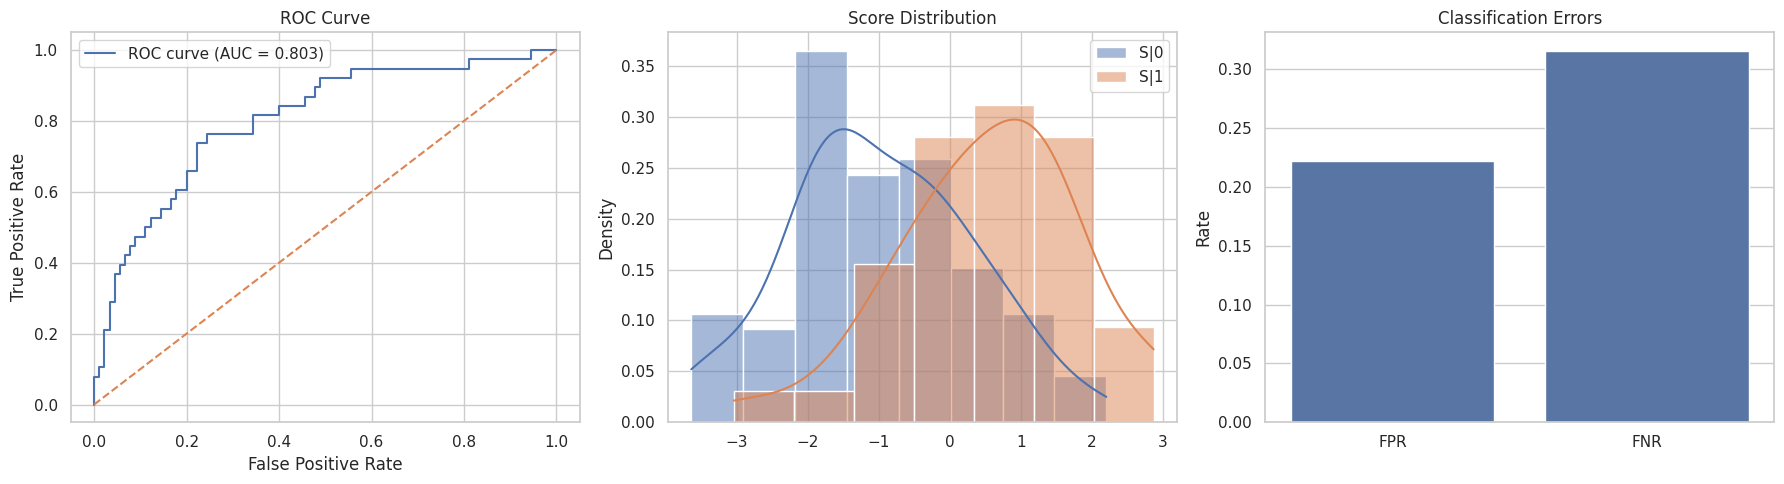

In [24]:
ct_3 = ColumnTransformer([('normaltransfer', QuantileTransformer(output_distribution='normal'),normal_feat,),
                        ('scaler',StandardScaler() , scaler_feat),
                        ('woe_cat', WoEEncoder(), column_types_X_train['categorical'])] )

pipe_prob_reg = Pipeline([('ct3',ct_3),
                        ('lg', LogisticRegression(penalty = 'l1', C = 13.89495494373136,class_weight= 'balanced', solver='liblinear', max_iter=20000))])


model_fit = pipe_prob_reg.fit(X_train, y_train)  # fit model
prob = model_fit.predict_proba(x_val)[:, 1]  # predict probs
confusion = confusion_matrix(y_val, model_fit.predict(x_val))  # confusion matrix

error = -sum(np.log(prob[prob>0]))/len(prob[prob>0])  # log error

fp_rate, tp_rate, _ = roc_curve(y_val, prob)
auc_test = auc(fp_rate, tp_rate)  # auc on test set

# conditional scores
s_0 = logit(model_fit.predict_proba(x_val)[np.where(y_val == 0)[0], 1])
s_1 = logit(model_fit.predict_proba(x_val)[np.where(y_val == 1)[0], 1])

display(Math(r"error = " + str(error.round(2))))
display(Math(r"auc = " + str(auc_test.round(3))))
result_plot(fp_rate, tp_rate,s_0, s_1, confusion, error, auc_test , y_val)

In [25]:
lg_coefs = pd.DataFrame(data = pipe_prob_reg.named_steps['lg'].coef_[0], index = X_train.columns,  columns = ['Coefficient']).sort_values(by = 'Coefficient', ascending = True)
lg_coefs

,Coefficient
installment_commitment,-0.138585
credit_history,-0.068837
credit_amount,-0.027402
duration,0.066833
employment,0.119154
savings_status,0.125842
foreign_worker,0.170899
own_telephone,0.236558
personal_status,0.250732
checking_status,0.277487


The magnitude of the standardized logistic regression coefficients indicates that housing, existing_credits, num_dependents, other_parties, residence_since, and age are among the most influential predictors of credit default. In contrast, credit_amount, duration, and credit_history exhibit relatively small coefficients, suggesting a weaker contribution to the model's classification performance.
These results are consistent with the exploratory data analysis, which showed substantial overlap between the default and non-default classes for credit_amount and duration. While these variables may still contribute useful information when combined with other predictors, they appear to have limited discriminatory power when considered individually.

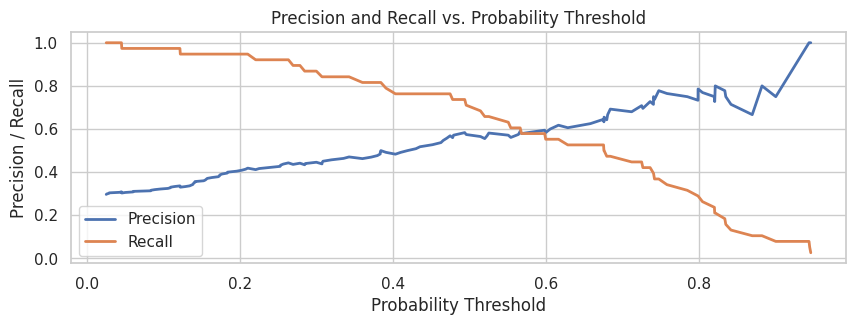

In [26]:
precision, recall, thresholds = precision_recall_curve(y_val, prob)
# Plot precision and recall vs. thresholds
plt.figure(figsize=(10, 3))
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
plt.xlabel('Probability Threshold')
plt.ylabel('Precision / Recall')
plt.title('Precision and Recall vs. Probability Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# precision focus on false positive (Tp /(Tp + Fp)), recall focus on false negative(Tp /(Tp + Fn)), cost of false negative > cost of false positive, or q > 1, which means fp> fn

In [28]:
# Create a DataFrame
pr_df = pd.DataFrame({
    'threshold': np.append(thresholds, 1.0),
    'precision': precision,
    'recall': recall
})

# Inspect the DataFrame
pr_df.sort_values('threshold', ascending = False).head(50)

,threshold,precision,recall
128,1.000000,1.000000,0.000000
127,0.946447,1.000000,0.026316
126,0.945019,1.000000,0.052632
125,0.944158,1.000000,0.078947
124,0.900695,0.750000,0.078947
123,0.882684,0.800000,0.105263
122,0.869945,0.666667,0.105263
121,0.842142,0.714286,0.131579
120,0.835372,0.750000,0.157895
119,0.834077,0.777778,0.184211


<div style="border-left: 4px solid #DCA8DB; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #f3e0f2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">Step Four: Point prediction</h1>  
  </div>
  <div style="padding: 1em;">
  <p>

- Using the logistic model built in the previous task, create a point predictor using a cut-off classifier.
- Display the confusion matrix and score distribution by true class for the training data.


</p></div></div>

In [29]:
x_val_4 =  x_val

# Generate predictions on test dataset
y_pred_proba = model_fit.predict_proba(x_val_4)[:, 1]

# Copy the test dataset to create an evaluation dataset
df_eval = x_val_4.copy().reset_index(drop=True)

# Set threshold
threshold = 0.55

# Store the prediction
df_eval = df_eval.assign(pred_proba=y_pred_proba, pred_is_fraud=(y_pred_proba >= threshold).astype(int), is_fraud=y_val.values) # add three columns pred_prob and pred_is_fraud

# Apply TP, TN, FP, FN
def apply_label(row, pred_col, label_col):
    if row[pred_col] == 1 and row[label_col] == 1:
        return 'TP'

    elif row[pred_col] == 0 and row[label_col] == 1:
        return 'FN'

    elif row[pred_col] == 1 and row[label_col] == 0:
        return 'FP'

    return 'TN'

df_eval['result'] = df_eval.apply(lambda x: apply_label(x, 'pred_is_fraud', 'is_fraud'), axis=1)

# Get percentage
pd.concat([
    df_eval['result'].value_counts(),
    df_eval['result'].value_counts(normalize=True).round(3)
], axis=1)

,count,proportion
result,,
TN,72,0.562
TP,24,0.188
FP,18,0.141
FN,14,0.109


In [30]:
from sklearn.metrics import classification_report

print(classification_report(df_eval['is_fraud'], df_eval['pred_is_fraud']))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        90
           1       0.57      0.63      0.60        38

    accuracy                           0.75       128
   macro avg       0.70      0.72      0.71       128
weighted avg       0.76      0.75      0.75       128



<div style="border-left: 4px solid #DCA8DB; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #f3e0f2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">Step Five: Model evaluation</h1>
  </div>
  <div style="padding: 1em;">
  <p>

- Use the model to perform both point and probabilistic classification on the test data.
- Display the ROC curve, AUC, confusion matrix and score distribution by true class.


</p></div></div>

Text(0, 0.5, 'Density')

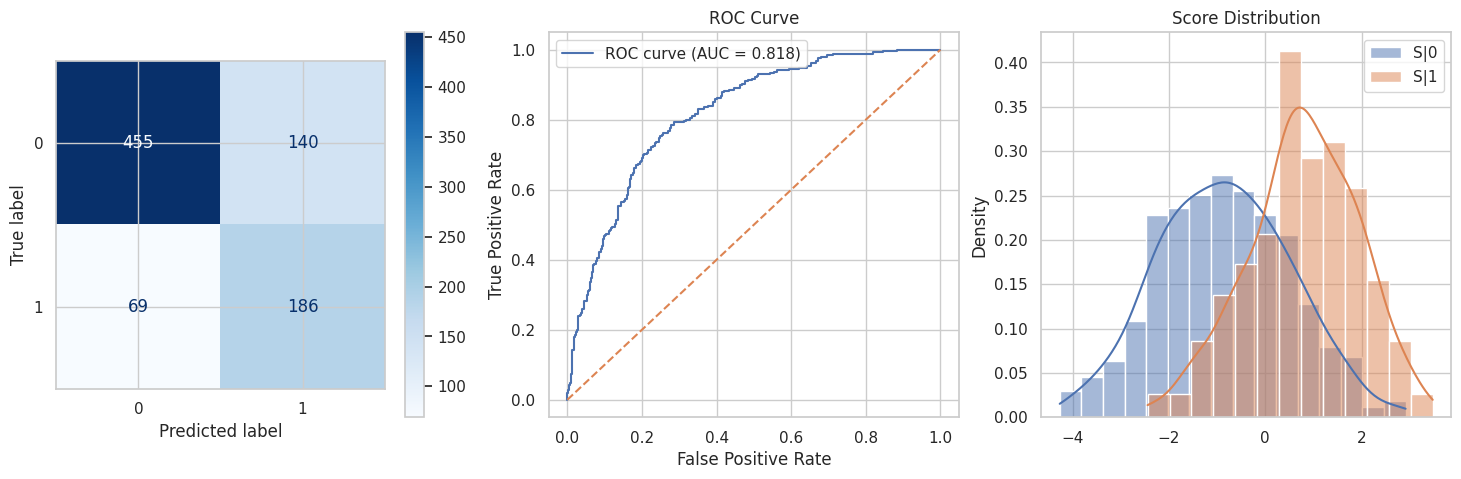

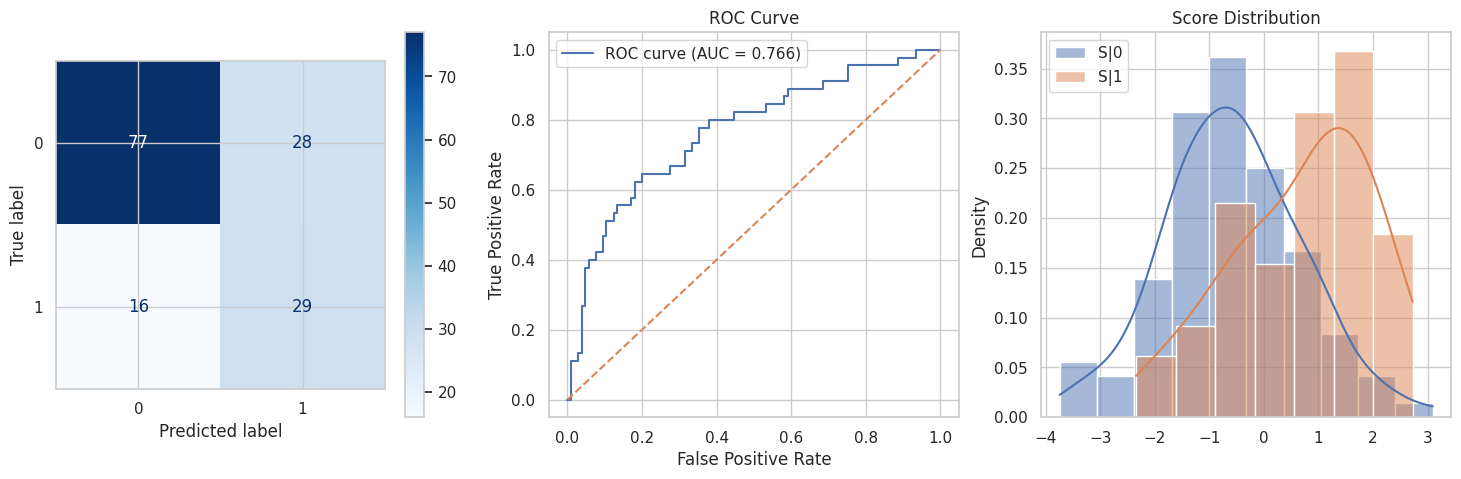

In [31]:
model_fit = pipe_prob_reg.fit(x_train, y_trai)  # fit mode

y_pred_proba_train = model_fit.predict_proba(x_train)[:, 1]
y_pred_proba_test = model_fit.predict_proba(X_test)[:, 1]

threshold = 0.55

# Store the prediction
df_eval_train = x_train.assign(pred_proba=y_pred_proba_train, pred_is_fraud=(y_pred_proba_train >= threshold).astype(int), is_fraud=y_trai.values) # add three columns pred_prob and pred_is_fraud
df_eval_test = X_test.assign(pred_proba=y_pred_proba_test, pred_is_fraud=(y_pred_proba_test >= threshold).astype(int), is_fraud=y_test.values) # add three columns pred_prob and pred_is_fraud

fp_rate_train, tp_rate_train, _ = roc_curve(df_eval_train['is_fraud'], df_eval_train['pred_proba'])
auc_train = auc(fp_rate_train, tp_rate_train)
fp_rate_test, tp_rate_test, _ = roc_curve(df_eval_test['is_fraud'], df_eval_test['pred_proba'])
auc_test = auc(fp_rate_test, tp_rate_test)

# conditional scores train
s_0_train = logit(model_fit.predict_proba(x_train)[np.where(y_trai == 0)[0], 1]) #log odds for all actual negatives
s_1_train = logit(model_fit.predict_proba(x_train)[np.where(y_trai == 1)[0], 1]) #log odds for all actual positive

# conditional scores test
s_0_test = logit(model_fit.predict_proba(X_test)[np.where(y_test == 0)[0], 1]) #log odds for all actual negatives
s_1_test = logit(model_fit.predict_proba(X_test)[np.where(y_test == 1)[0], 1]) #log odds for all actual positive

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(df_eval_train['is_fraud'], df_eval_train['pred_is_fraud'], cmap="Blues", ax = axes[0])

# ROC curve
axes[1].plot(fp_rate_train, tp_rate_train, label=f'ROC curve (AUC = {auc_train:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True)

# Score distributions
sns.histplot(x=s_0_train, stat='density', label='S|0', ax=axes[2], kde=True)
sns.histplot(x=s_1_train, stat='density', label='S|1', ax=axes[2], kde=True)
axes[2].set_title('Score Distribution')
axes[2].legend()
axes[2].set_ylabel('Density')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(df_eval_test['is_fraud'], df_eval_test['pred_is_fraud'], cmap="Blues",ax = axes[0])
# ROC curve
axes[1].plot(fp_rate_test, tp_rate_test, label=f'ROC curve (AUC = {auc_test:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True)

# Score distributions
sns.histplot(x=s_0_test, stat='density', label='S|0', ax=axes[2], kde=True)
sns.histplot(x=s_1_test, stat='density', label='S|1', ax=axes[2], kde=True)
axes[2].set_title('Score Distribution')
axes[2].legend()
axes[2].set_ylabel('Density')


The selected logistic regression model achieved an AUC of 0.81 on the training set and 0.76 on the test set. The modest decrease in performance suggests a small degree of overfitting; however, the model maintains good generalization ability on unseen data.
It should be noted that the exploratory data analysis revealed substantial overlap between the default and non-default classes for several numerical variables, and some relationships between the predictors and the target may be nonlinear. Consequently, more flexible machine learning models, such as Random Forests, Gradient Boosting, or XGBoost, may be able to capture complex interactions and nonlinear patterns that are not fully exploited by logistic regression, potentially leading to improved predictive performance.

<div style="border-left: 4px solid #DCA8DB; border-radius: 5px; background-color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15); overflow: hidden;">
  <div style="background-color: #f3e0f2; padding: 1em;">
    <h1 style="font-weight: bold; font-size: 20px;">Step Six: Model application</h1>
  </div>
  <div style="padding: 1em;">
  <p>

A new applicant’s data is provided separately.

- Apply the probabilistic predictor and point classifier to this applicant's data.
- Based on the threshold and probability estimate, decide whether to recommend extending credit.


</p></div></div>

In [32]:
# new data for an applicant
new_applicant_data_raw = {
    'checking_status': '0<=X<200',
    'duration': 12,
    'credit_history': 'existing paid',
    'purpose': 'furniture/equipment',
    'credit_amount': 1845,
    'savings_status': '<100',
    'employment': '4<=X<7',
    'installment_commitment': 2,
    'personal_status': 'male div/sep',
    'other_parties': 'guarantor',
    'residence_since': 3,
    'property_magnitude': 'no known property',
    'age': 52,
    'other_payment_plans': 'none',
    'housing': 'own',
    'existing_credits': 1,
    'job': 'unskilled resident',
    'num_dependents': 1,
    'own_telephone': 'yes',
    'foreign_worker': 'yes',
    'class': 'good',
}
new_applicant = pd.DataFrame([new_applicant_data_raw], columns=credit_risk.columns)
new_applicant = new_applicant.astype(credit_risk.dtypes.to_dict())

new_applicant['class'] = new_applicant['class'].replace(['good','bad'], [0,1]).astype(int)
new_applicant['foreign_worker'] = new_applicant['foreign_worker'].replace(['yes','no'], [1,0]).astype(int)
new_applicant['own_telephone'] = new_applicant['own_telephone'].replace(['none','yes'], [0,1]).astype(int)

mapping = {"radio/tv": "furniture/equipment/appliance","furniture/equipment": "furniture/equipment/appliance","domestic appliance": "furniture/equipment/appliance",
            "new car": "vehicle", "used car": "vehicle",
            "business": "income_investment","education": "income_investment","retraining": "income_investment",
            "repairs": "repairs/other","other": "repairs/other"}

new_applicant["purpose"] = new_applicant["purpose"].map(mapping)



y_pred_new_applicant = model_fit.predict_proba(new_applicant)[:, 1]

# Store the prediction
df_eval_train = new_applicant.assign(pred_proba=y_pred_new_applicant, pred_is_fraud=(y_pred_new_applicant >= threshold).astype(int))

df_eval_train[['pred_proba','pred_is_fraud']]

,pred_proba,pred_is_fraud
0,0.41206,0


The logistic regression model estimated a probability of default of 0.412 (41.2%) for the new applicant. Using the selected classification threshold of 0.55, the applicant is classified as a non-default customer because the estimated probability of default is below the decision threshold.

$$
P(\text{default}) = 0.412 < 0.55
$$

Therefore, the model recommends extending credit to the applicant.
From a statistical perspective, the classification follows directly from the model's decision rule. The estimated probability of default does not exceed the threshold established during model validation.
From a risk management perspective, the applicant exhibits several favorable characteristics, including a relatively mature age, stable employment history, home ownership, a modest loan amount, and a positive credit history. While the estimated probability of default is not negligible, it remains below the institution's acceptance threshold. Consequently, the applicant would be approved for credit, potentially with appropriate risk controls such as a lower credit limit or enhanced monitoring.